In [7]:
import os

print(os.getcwd())
print(os.listdir("../results"))

import pandas as pd

hydrazide_df = pd.read_csv("../data/hydrazide_library.csv")


d:\triazine_qspr_project\notebooks
['descriptors.csv', 'filtered_hydrazide.csv', 'similarity_matrix.csv', 'triazine_dataset.csv']


In [9]:
from rdkit import Chem
from rdkit.Chem import Descriptors

hydrazide_df["mol"] = hydrazide_df["SMILES"].apply(
    Chem.MolFromSmiles
)

hydrazide_df["mol"].isnull().sum()

hydrazide_df = hydrazide_df[
    hydrazide_df["mol"].notnull()
]

[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not removing hydrogen atom without neighbors
[11:01:44] WARNING: not r

In [10]:
hydrazide_df["mol"] = hydrazide_df["SMILES"].apply(
    Chem.MolFromSmiles
)
hydrazide_df["TPSA"] = hydrazide_df["mol"].apply(
    Descriptors.TPSA
)
hydrazide_df[["SMILES", "TPSA"]].head()

filtered_df = hydrazide_df[
    (hydrazide_df["Molecular_Weight"] < 500) &
    (hydrazide_df["XLogP"] < 5.0) &
    (hydrazide_df["Rotatable_Bond_Count"] < 10) &
    (hydrazide_df["TPSA"] < 150)
]
len(filtered_df)

[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not removing hydrogen atom without neighbors
[11:01:50] WARNING: not r

7475

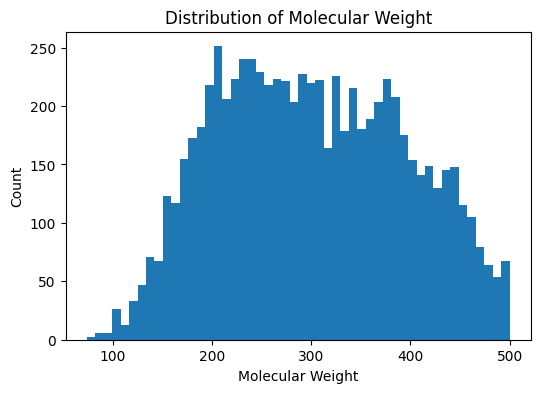

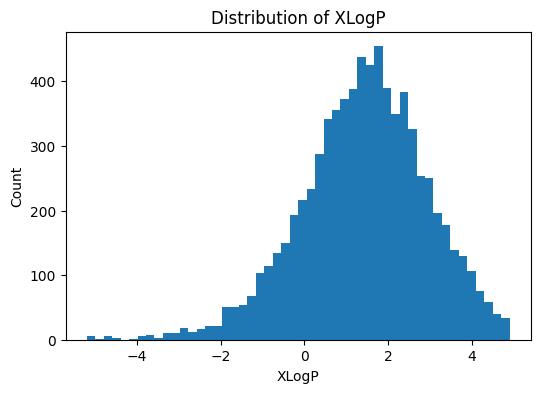

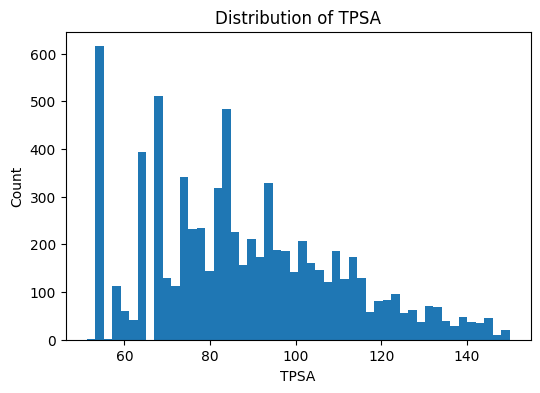

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(filtered_df["Molecular_Weight"], bins=50)
plt.xlabel("Molecular Weight")
plt.ylabel("Count")
plt.title("Distribution of Molecular Weight")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(filtered_df["XLogP"], bins=50)
plt.xlabel("XLogP")
plt.ylabel("Count")
plt.title("Distribution of XLogP")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(filtered_df["TPSA"], bins=50)
plt.xlabel("TPSA")
plt.ylabel("Count")
plt.title("Distribution of TPSA")
plt.show()

In [12]:
from rdkit.Chem import Descriptors

filtered_df["Aromatic_Rings"] = filtered_df["mol"].apply(
    Descriptors.NumAromaticRings
)

filtered_df["Aromatic_Rings"].value_counts().sort_index()

Aromatic_Rings
0     620
1    2601
2    2652
3    1345
4     249
5       7
6       1
Name: count, dtype: int64

In [13]:
filtered_df[filtered_df["Aromatic_Rings"] == 0]
len(filtered_df[filtered_df["Aromatic_Rings"] == 0])

620

In [14]:
filtered_df = filtered_df[
    filtered_df["Aromatic_Rings"] > 0
]
len(filtered_df)

6855

In [15]:
filtered_df.to_csv(
    "../results/filtered_hydrazide.csv",
    index=False
)

In [20]:
from rdkit.Chem import rdMolDescriptors
filtered_df["N_atoms"] = filtered_df["SMILES"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==7
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

filtered_df["O_atoms"] = filtered_df["SMILES"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==8
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

filtered_df["S_atoms"] = filtered_df["SMILES"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==16
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

halogens = [9,17,35,53]

filtered_df["Halogen_atoms"] = filtered_df["SMILES"].apply(
    lambda s: sum(
        atom.GetAtomicNum() in halogens
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

filtered_df["Hetero_atoms"] = filtered_df["SMILES"].apply(
    lambda s: sum(
        atom.GetAtomicNum() not in [1,6]
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

filtered_df["Ring_count"] = filtered_df["SMILES"].apply(
    lambda s:
    rdMolDescriptors.CalcNumRings(
        Chem.MolFromSmiles(s)
    )
)

filtered_df[["Name","N_atoms","O_atoms","S_atoms","Halogen_atoms","Hetero_atoms","Ring_count"]]

,Name,N_atoms,O_atoms,S_atoms,Halogen_atoms,Hetero_atoms,Ring_count
0,Isoniazid,3,1,0,0,4,1
3,Benzoylhydrazine,2,1,0,0,3,1
5,4-Aminobenzoic acid hydrazide,3,1,0,0,4,1
6,4-Bromobenzohydrazide,2,1,0,1,4,1
7,4-Methoxybenzohydrazide,2,2,0,0,4,1
...,...,...,...,...,...,...,...
9993,"2-(2,2-Difluoroacetyl)-3-fluoro-4-methylbenzoh...",2,2,0,3,7,1
9995,"N-[3-[(1,1-dioxo-1,4-thiazinan-2-yl)methyl]phe...",4,5,2,1,12,3
9997,"1,1-dichloro-N-(3-chlorophenyl)-N-[[2-fluoro-4...",3,3,1,4,11,2
9998,N-[[2-fluoro-4-(hydrazinecarbonyl)phenyl]methy...,3,2,0,2,7,2
